In [19]:
import pandas as pd
import yaml
from utils.process_data import make_dataset

data = pd.read_csv("input/processed/data.csv", index_col=0, parse_dates=True)

with open("config.yaml") as f:
    config = yaml.safe_load(f)

X, y = make_dataset(data, config["TreeModel"])

In [33]:
model_config = config["TreeModel"]
cols = model_config["features"] + [f"lag_{i}" for i in model_config["lags"]]
corr_df = pd.DataFrame(corr, columns=cols, index=cols)

In [ ]:
data.is_holiday.desribe()

DateTime
2015-01-11 23:00:00+00:00    0
2015-01-12 00:00:00+00:00    0
2015-01-12 01:00:00+00:00    0
2015-01-12 02:00:00+00:00    0
2015-01-12 03:00:00+00:00    0
                            ..
2025-07-25 17:00:00+00:00    0
2025-07-25 18:00:00+00:00    0
2025-07-25 19:00:00+00:00    0
2025-07-25 20:00:00+00:00    0
2025-07-25 21:00:00+00:00    0
Name: is_holiday, Length: 92351, dtype: int64

Baseline accuracy on test data: 0.95


c:\Users\c.fusarbassini\Desktop\day_ahead_forecasting\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\c.fusarbassini\Desktop\day_ahead_forecasting\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


ValueError: Distance matrix 'X' must be symmetric.

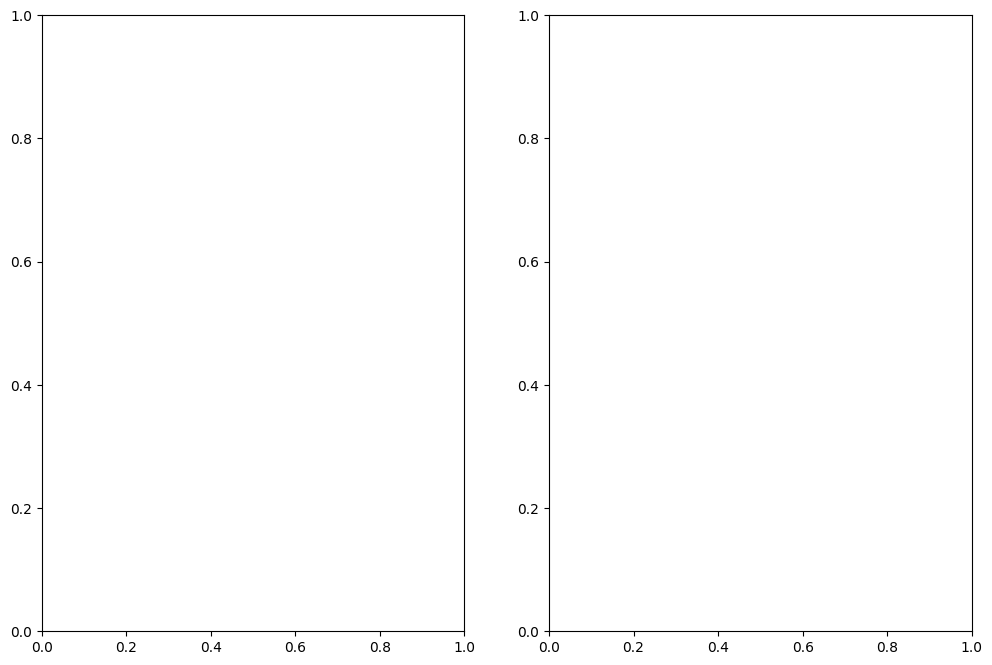

In [23]:
data = pd.read_csv("input/processed/data.csv", index_col=0, parse_dates=True)

from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from scipy.stats import spearmanr
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt 
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.2, test_size=0.1, random_state=42)

clf = RandomForestRegressor(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
print(f"Baseline accuracy on test data: {clf.score(X_test, y_test):.2}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))
corr = spearmanr(X).correlation

# Ensure the correlation matrix is symmetric
corr = (corr + corr.T) / 2
np.fill_diagonal(corr, 1)

# We convert the correlation matrix to a distance matrix before performing
# hierarchical clustering using Ward's linkage.
distance_matrix = 1 - np.abs(corr)
dist_linkage = hierarchy.ward(squareform(distance_matrix))
dendro = hierarchy.dendrogram(
    dist_linkage, labels=X.columns.to_list(), ax=ax1, leaf_rotation=90
)
dendro_idx = np.arange(0, len(dendro["ivl"]))

ax2.imshow(corr[dendro["leaves"], :][:, dendro["leaves"]])
ax2.set_xticks(dendro_idx)
ax2.set_yticks(dendro_idx)
ax2.set_xticklabels(dendro["ivl"], rotation="vertical")
ax2.set_yticklabels(dendro["ivl"])
_ = fig.tight_layout()
